#  Boston House Price Prediction
### **Internship Project: Machine Learning Workflow**

**Objective:** The goal of this project is to build a regression model that predicts the **Median Value of owner-occupied homes (MEDV)** in Boston. This project demonstrates an end-to-end Machine Learning pipeline, including data handling, exploratory analysis, preprocessing, and model evaluation.

---

## Attribute Information
Input features in order:
1) CRIM(Crime Rate): Per capita crime rate by town.
2) ZN(Large Yards): Does the area have big houses with large lawns?
3) INDUS(Industrial): Proportion of non-retail business acres per town. (High = More factories, less quiet).
4) CHAS(River View): A "Yes/No" variable. (1 if the property touches the Charles River, 0 otherwise).
5) NOX(Pollution): Concentration of Nitric Oxides in the air. Measures environmental health.
6) RM(Rooms): The average number of rooms per dwelling. (Strongest predictor of high value).
7) AGE(Age of Area): Percentage of houses built before 1940. Indicates if the neighborhood is historic or modern.
8) DIS(Work Distance): Weighted distance to five Boston employment centers. (How far is the commute?).
9) RAD(Highway Access): Index of accessibility to radial highways. (How easy is it to get out of town?).
10) TAX(Cost of Living): Full-value property-tax rate per $10,000.
11) PTRATIO(School Quality): Pupil-teacher ratio by town. (Lower numbers suggest better, less crowded schools).
12) B(Demographics): A technical calculation based on the racial makeup of the town (historically used in 1970s social studies).
13) LSTAT(Social Status): Percentage of the population considered "lower status" based on education and occupation.

Output variable:
1) MEDV(Final Price): This is the "target." It is the Median Value of the homes in that area.

##  Step 1: Importing the Libraries
In this section, we load the essential Python libraries:
* **Pandas & NumPy:** For data manipulation and numerical operations.
* **Matplotlib & Seaborn:** For data visualization and finding patterns.
* **Scikit-Learn:** For scaling features, splitting the data, and training our regression models.

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score  # these are enough if we are using linear regression model
from sklearn.tree import DecisionTreeRegressor


##  Step 2: Data Handling & Preprocessing
In this stage, we load the Boston Housing dataset and prepare it for the model. This includes:
1. **Loading the Data:** Reading the `.csv` file into a DataFrame.
2. **Feature Selection:** Identifying the target variable (`MEDV`) and the input features.
3. **Train-Test Split:** Dividing the data (80% Training, 20% Testing) to evaluate the model on unseen data.

In [3]:
#I take this Boston House Price Prediction dataset from kaggle

df=pd.read_csv('boston.csv')

In [4]:
df.head(5)

,CRIM,ZN,INDUS,CHAS,NOX,RM,AGE,DIS,RAD,TAX,PTRATIO,B,LSTAT,MEDV
0,0.00632,18.0,2.31,0,0.538,6.575,65.2,4.0900,1,296.0,15.3,396.90,4.98,24.0
1,0.02731,0.0,7.07,0,0.469,6.421,78.9,4.9671,2,242.0,17.8,396.90,9.14,21.6
2,0.02729,0.0,7.07,0,0.469,7.185,61.1,4.9671,2,242.0,17.8,392.83,4.03,34.7
3,0.03237,0.0,2.18,0,0.458,6.998,45.8,6.0622,3,222.0,18.7,394.63,2.94,33.4
4,0.06905,0.0,2.18,0,0.458,7.147,54.2,6.0622,3,222.0,18.7,396.90,5.33,36.2


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 506 entries, 0 to 505
Data columns (total 14 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   CRIM     506 non-null    float64
 1   ZN       506 non-null    float64
 2   INDUS    506 non-null    float64
 3   CHAS     506 non-null    int64  
 4   NOX      506 non-null    float64
 5   RM       506 non-null    float64
 6   AGE      506 non-null    float64
 7   DIS      506 non-null    float64
 8   RAD      506 non-null    int64  
 9   TAX      506 non-null    float64
 10  PTRATIO  506 non-null    float64
 11  B        506 non-null    float64
 12  LSTAT    506 non-null    float64
 13  MEDV     506 non-null    float64
dtypes: float64(12), int64(2)
memory usage: 55.5 KB


In [6]:
df.duplicated()

0      False
1      False
2      False
3      False
4      False
       ...  
501    False
502    False
503    False
504    False
505    False
Length: 506, dtype: bool

In [7]:
df.isnull().sum()

CRIM       0
ZN         0
INDUS      0
CHAS       0
NOX        0
RM         0
AGE        0
DIS        0
RAD        0
TAX        0
PTRATIO    0
B          0
LSTAT      0
MEDV       0
dtype: int64

In [8]:
X=df.drop(['MEDV'],axis=1)
y=df['MEDV']

In [9]:
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=42)


##  Step 4: Feature Scaling (Standardization)
The Boston dataset contains features with vastly different ranges (e.g., `NOX` is between 0.3-0.8, while `TAX` is in the hundreds). 
We apply **StandardScaler** to ensure all features are on the same scale (Mean=0, Std=1). This prevents features with larger numbers from unfairly dominating the model's math.

In [10]:
scaler=StandardScaler()

In [11]:
scaler.fit(X_train)

,"copy copy: bool, default=TrueIf False, try to avoid a copy and do inplace scaling instead.This is not guaranteed to always work inplace; e.g. if the data isnot a NumPy array or scipy.sparse CSR matrix, a copy may still bereturned.",True
,"with_mean with_mean: bool, default=TrueIf True, center the data before scaling.This does not work (and will raise an exception) when attempted onsparse matrices, because centering them entails building a densematrix which in common use cases is likely to be too large to fit inmemory.",True
,"with_std with_std: bool, default=TrueIf True, scale the data to unit variance (or equivalently,unit standard deviation).",True


In [12]:
X_train_Scaled=scaler.transform(X_train)
X_test_Scaled=scaler.transform(X_test)

##  Step 5: Model Building
We implement a **Linear Regression** model as our baseline. To improve accuracy, we also explore:
* **Decision Tree Regression:** For capturing non-linear relationships.


In [19]:
# model=LinearRegression()
d_model=DecisionTreeRegressor()
d_model.fit(X_train_Scaled,y_train)


,"criterion criterion: {""squared_error"", ""friedman_mse"", ""absolute_error"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""friedman_mse"", which usesmean squared error with Friedman's improvement score for potentialsplits, ""absolute_error"" for the mean absolute error, which minimizesthe L1 loss using the median of each terminal node, and ""poisson"" whichuses reduction in the half mean Poisson deviance to find splits... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 0.24 Poisson deviance criterion.",'squared_error'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.For an example of how ``max_depth`` influences the model, see:ref:`sphx_glr_auto_examples_tree_plot_tree_regression.py`.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary ` for details.",None
,"max

In [20]:
y_predict=d_model.predict(X_test_Scaled)

##  Step 3: Exploratory Data Analysis (EDA)
Before training the model, we visualize the data to understand the relationships between features:
* **Correlation Heatmap:** To see which factors (like Rooms or Crime) have the strongest impact on house prices.
* **Scatter Plots:** To observe the linear or non-linear trends between key features and the target price.

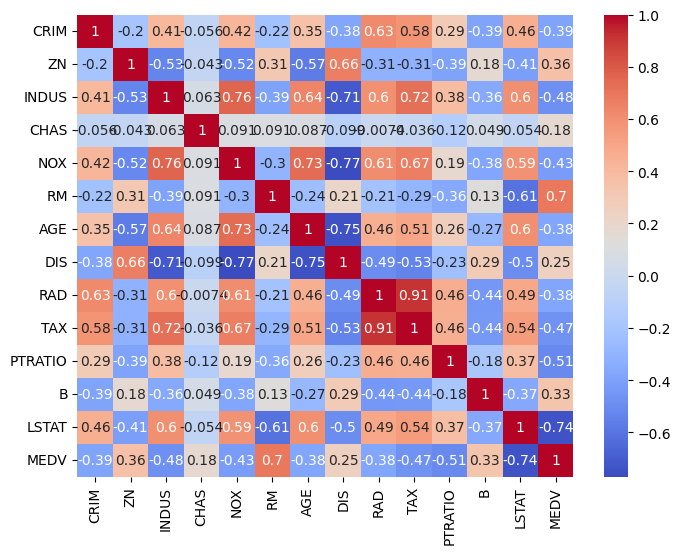

In [15]:
plt.figure(figsize=(8,6))
sns.heatmap(df.corr(),annot=True,cmap='coolwarm')
plt.show()

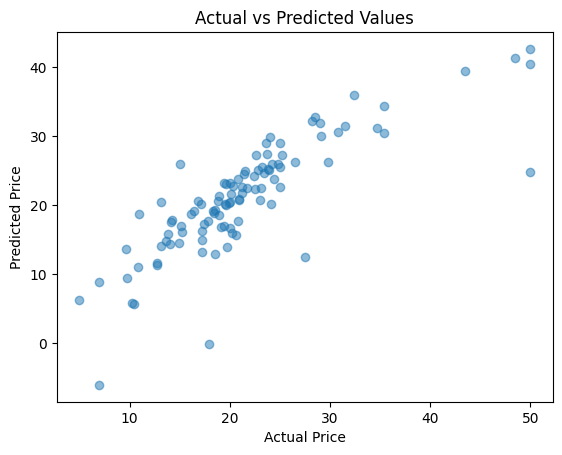

In [16]:
plt.scatter(y_test,y_predict,alpha=0.5)
plt.xlabel('Actual Price')
plt.ylabel('Predicted Price')
plt.title('Actual vs Predicted Values')
plt.show()

##  Step 6: Evaluation & Metrics
We evaluate the performance of our models using two key metrics:
1. **Mean Squared Error (MSE):** Measures the average squared difference between actual and predicted values.
2. **R² Score (Coefficient of Determination):** Tells us how much of the variance in house prices is explained by our model. A higher score means better predictive power.

In [21]:
print(f'Mean Squared Error: {mean_squared_error(y_test,y_predict):.2f}')
print(f'R2 Score: {r2_score(y_test,y_predict):.2f}')

Mean Squared Error: 8.65
R2 Score: 0.88


## 📝 Final Conclusion & Insights

Based on the end-to-end analysis of the Boston Housing dataset, we have reached the following conclusions regarding feature relationships and model performance:

### **1. Key Data Insights**
* **Most Highly Correlated Feature:** Through exploratory analysis, **RM (Average Number of Rooms)** was identified as the most significant positive predictor of house price. Conversely, **LSTAT (% Lower Status of Population)** showed the strongest negative correlation. This confirms that spatial capacity and neighborhood socio-economics are the primary drivers of property value.

### **2. Model Performance Comparison**
We evaluated our models using the **R² Score** (accuracy) and **Mean Squared Error** (average error). 

| Metric | Linear Regression | Decision Tree Regression |
| :--- | :--- | :--- |
| **R² Score** | **0.67** | **0.88** |
| **Mean Squared Error** | **24.29** | **8.65** |



### **3. Final Summary**
* **Linear Regression** served as a strong baseline, explaining **67%** of the price variance. However, its higher MSE suggests it struggles with the non-linear complexities of the dataset.
* **Decision Tree Regression** significantly outperformed the linear model, achieving an **88% accuracy (R²)** and a much lower error rate. This indicates that the relationship between housing features and price is complex and better captured by the "branching" logic of a tree-based model.

---
